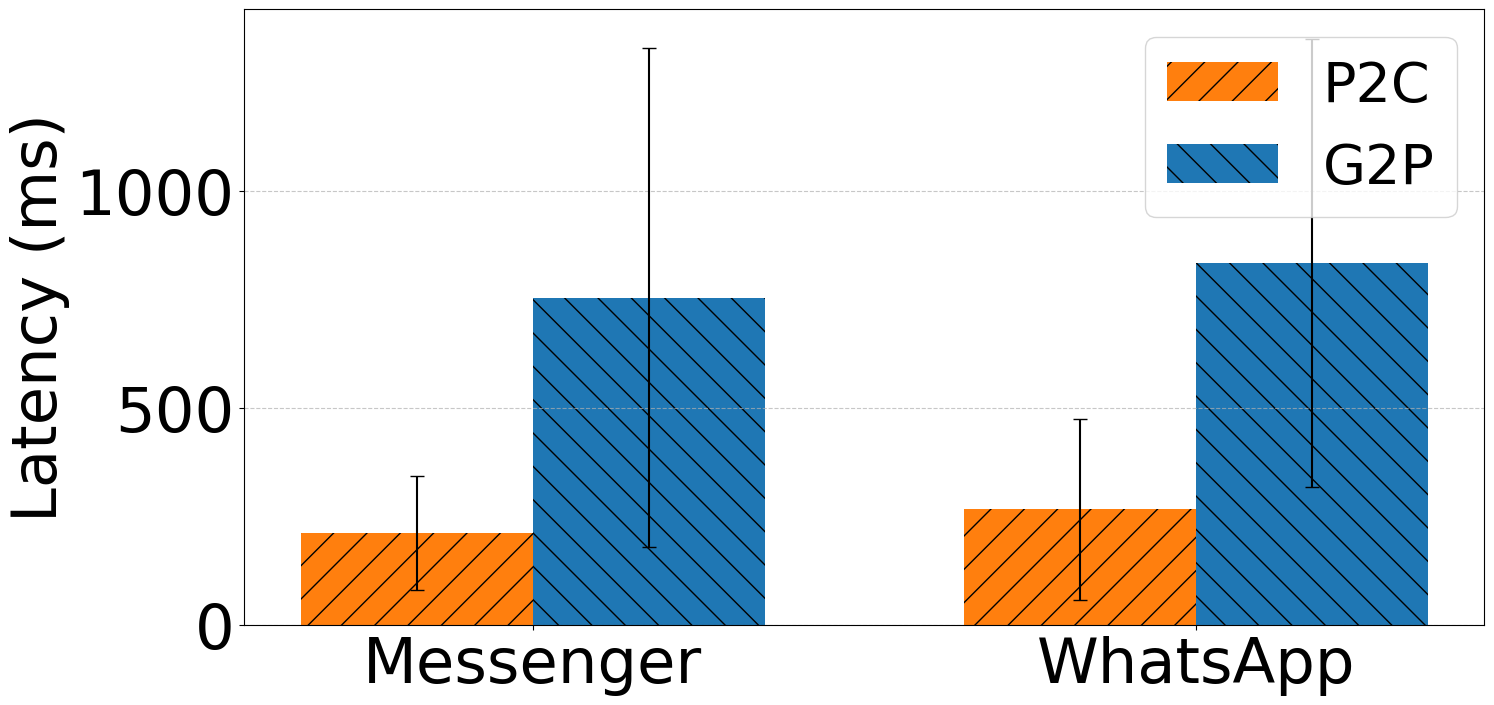

In [4]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# Read the CSV files
df_messenger = pd.read_csv('Messenger_Latency_Results.csv')
df_whatsapp = pd.read_csv('Whatsapp_Latency_Results.csv')

# Extract the data for the 15 tests (exclude the average row)
p2c_messenger = df_messenger['P2C (ms)'][:-1].values
g2p_messenger = df_messenger['G2P(ms)'][:-1].values

# Note: WhatsApp column names have extra spaces
p2c_whatsapp = df_whatsapp['P2C  (ms)'][:-1].values
g2p_whatsapp = df_whatsapp['G2P (ms)'][:-1].values

# Calculate means and standard deviations
mean_p2c_messenger = np.mean(p2c_messenger)
mean_g2p_messenger = np.mean(g2p_messenger)
mean_p2c_whatsapp = np.mean(p2c_whatsapp)
mean_g2p_whatsapp = np.mean(g2p_whatsapp)

std_p2c_messenger = np.std(p2c_messenger, ddof=1)
std_g2p_messenger = np.std(g2p_messenger, ddof=1)
std_p2c_whatsapp = np.std(p2c_whatsapp, ddof=1)
std_g2p_whatsapp = np.std(g2p_whatsapp, ddof=1)

# Data for plotting
apps = ['Messenger', 'WhatsApp']
p2c_means = [mean_p2c_messenger, mean_p2c_whatsapp]
g2p_means = [mean_g2p_messenger, mean_g2p_whatsapp]
p2c_stds = [std_p2c_messenger, std_p2c_whatsapp]
g2p_stds = [std_g2p_messenger, std_g2p_whatsapp]

# Create the grouped bar plot
x = np.arange(len(apps))  # the label locations
width = 0.35  # the width of the bars

plt.figure(figsize=(16, 8))
plt.rcParams.update({'font.size': 45})

# Bars for P2C
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.bar(x - width/2, p2c_means, width, yerr=p2c_stds, capsize=5, label='P2C', color='#ff7f0e', hatch='/')

# Bars for G2P
plt.bar(x + width/2, g2p_means, width, yerr=g2p_stds, capsize=5, label='G2P', color='#1f77b4', hatch='\\')

plt.ylabel('Latency (ms)')
plt.xticks(x, apps)
plt.legend(loc='upper right', fontsize=40)
plt.savefig('../../Plots/Latency_Comparison_Messenger_WhatsApp.png', dpi=300)
plt.show()
